In [136]:
from __future__ import division
import numpy as np
import matplotlib.pyplot as plt
import sys

intp = 10  #tomar uno de cada cien valores, para graficar rapido
BSIZE_SP = 512 # Max size of a line of data; we don't want to read the
               # whole file to find a line, in case file does not have
               # expected structure.

MDATA_LIST = [b'title', b'date', b'plotname', b'flags', b'no. variables',
              b'no. points', b'dimensions', b'command', b'option']

def rawread(fname: str):
    """Read ngspice binary raw files. Return tuple of the data, and the
    plot metadata. The dtype of the data contains field names. This is
    not very robust yet, and only supports ngspice.
    
    >>> darr, mdata = rawread('test.py')
    >>> darr.dtype.names
    >>> plot(np.real(darr['frequency']), np.abs(darr['v(out)']))
    """
    # Example header of raw file
    # Title: rc band pass example circuit
    # Date: Sun Feb 21 11:29:14  2016
    # Plotname: AC Analysis
    # Flags: complex
    # No. Variables: 3
    # No. Points: 41
    # Variables:
    #         0       frequency       frequency       grid=3
    #         1       v(out)  voltage
    #         2       v(in)   voltage
    # Binary:
    fp = open(fname, 'rb')
    arrs = []
    plots = []
    plot = {}
    while (True):
        try:
            # mdata = fp.readline(BSIZE_SP).split(b':', maxsplit=1)
            mdata = fp.readline().split(b':', maxsplit=1)
        except:
            raise
        if len(mdata) == 2:
            if mdata[0].lower() in MDATA_LIST:
                plot[mdata[0].lower()] = mdata[1].strip()
            if mdata[0].lower() == b'variables':
                nvars = int(plot[b'no. variables'])
                npoints = int(plot[b'no. points'])
                plot['varnames'] = []
                plot['varunits'] = []
                for varn in range(nvars):
                    # varspec = (fp.readline(BSIZE_SP).strip().decode('ascii').split())
                    varspec = (fp.readline().strip().decode('ascii').split())
                    assert(varn == int(varspec[0]))
                    plot['varnames'].append(varspec[1])
                    plot['varunits'].append(varspec[2])
            if mdata[0].lower() == b'binary':
                rowdtype = np.dtype({'names': plot['varnames'],
                                     'formats': [np.complex_ if b'complex'
                                                 in plot[b'flags']
                                                 else np.float64]*nvars})
                # We should have all the metadata by now
                arrs.append(np.fromfile(fp, dtype=rowdtype, count=npoints))
                plots.append(plot)
                plot = {} # reset the plot dict
                fp.readline() # Read to the end of line
        else:
            break
    return (arrs[0], plots)

data, dicc = rawread("tb_cb_3x3_spk.raw")


In [137]:
dicc

[{b'title': b'** sch_path: /foss/designs/snn-buck-boost/synapse/tb_cb_3x3_spk.sch',
  b'date': b'Tue Mar 17 17:26:06  2026',
  b'command': b'ngspice-45.2, Build Sun Dec 21 19:31:43 UTC 2025',
  b'plotname': b'Transient Analysis',
  b'flags': b'real',
  b'no. variables': b'130',
  b'no. points': b'13973',
  'varnames': ['time',
   'v(m.x1.xm1.msky130_fd_pr__pfet_01v8#body)',
   'v(m.x1.xm1.msky130_fd_pr__pfet_01v8#dbody)',
   'v(m.x1.xm1.msky130_fd_pr__pfet_01v8#sbody)',
   'v(m.x1.xm2.msky130_fd_pr__pfet_01v8#body)',
   'v(m.x1.xm2.msky130_fd_pr__pfet_01v8#dbody)',
   'v(m.x1.xm2.msky130_fd_pr__pfet_01v8#sbody)',
   'v(m.x1.xm3.msky130_fd_pr__pfet_01v8#body)',
   'v(m.x1.xm3.msky130_fd_pr__pfet_01v8#dbody)',
   'v(m.x1.xm3.msky130_fd_pr__pfet_01v8#sbody)',
   'v(m.x1.xm4.msky130_fd_pr__pfet_01v8#body)',
   'v(m.x1.xm4.msky130_fd_pr__pfet_01v8#dbody)',
   'v(m.x1.xm4.msky130_fd_pr__pfet_01v8#sbody)',
   'v(m.x1.xm5.msky130_fd_pr__pfet_01v8#body)',
   'v(m.x1.xm5.msky130_fd_pr__pfet_01v8

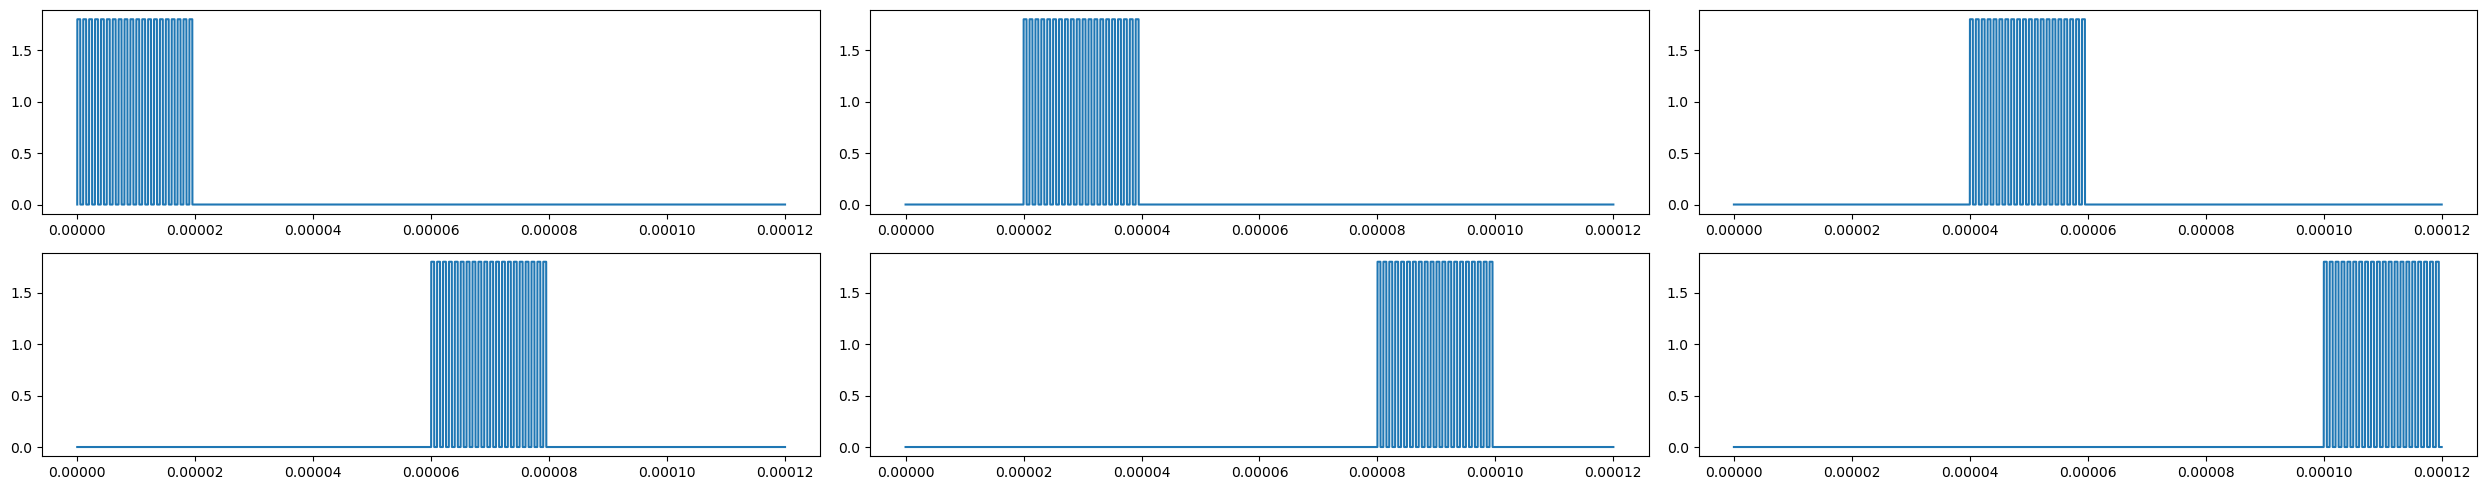

In [145]:


fig, axes = plt.subplots(2, 3, figsize=(25,5))

# Loop through each subplot
for i in range(2):
    for j in range(3):
        axes[i, j].plot(data["time"], data[f"v(n{i+1}{j+1})"], label = f"n{i+1}{j+1}")

# Adjust spacing
plt.tight_layout()

# Show the figure
plt.show()



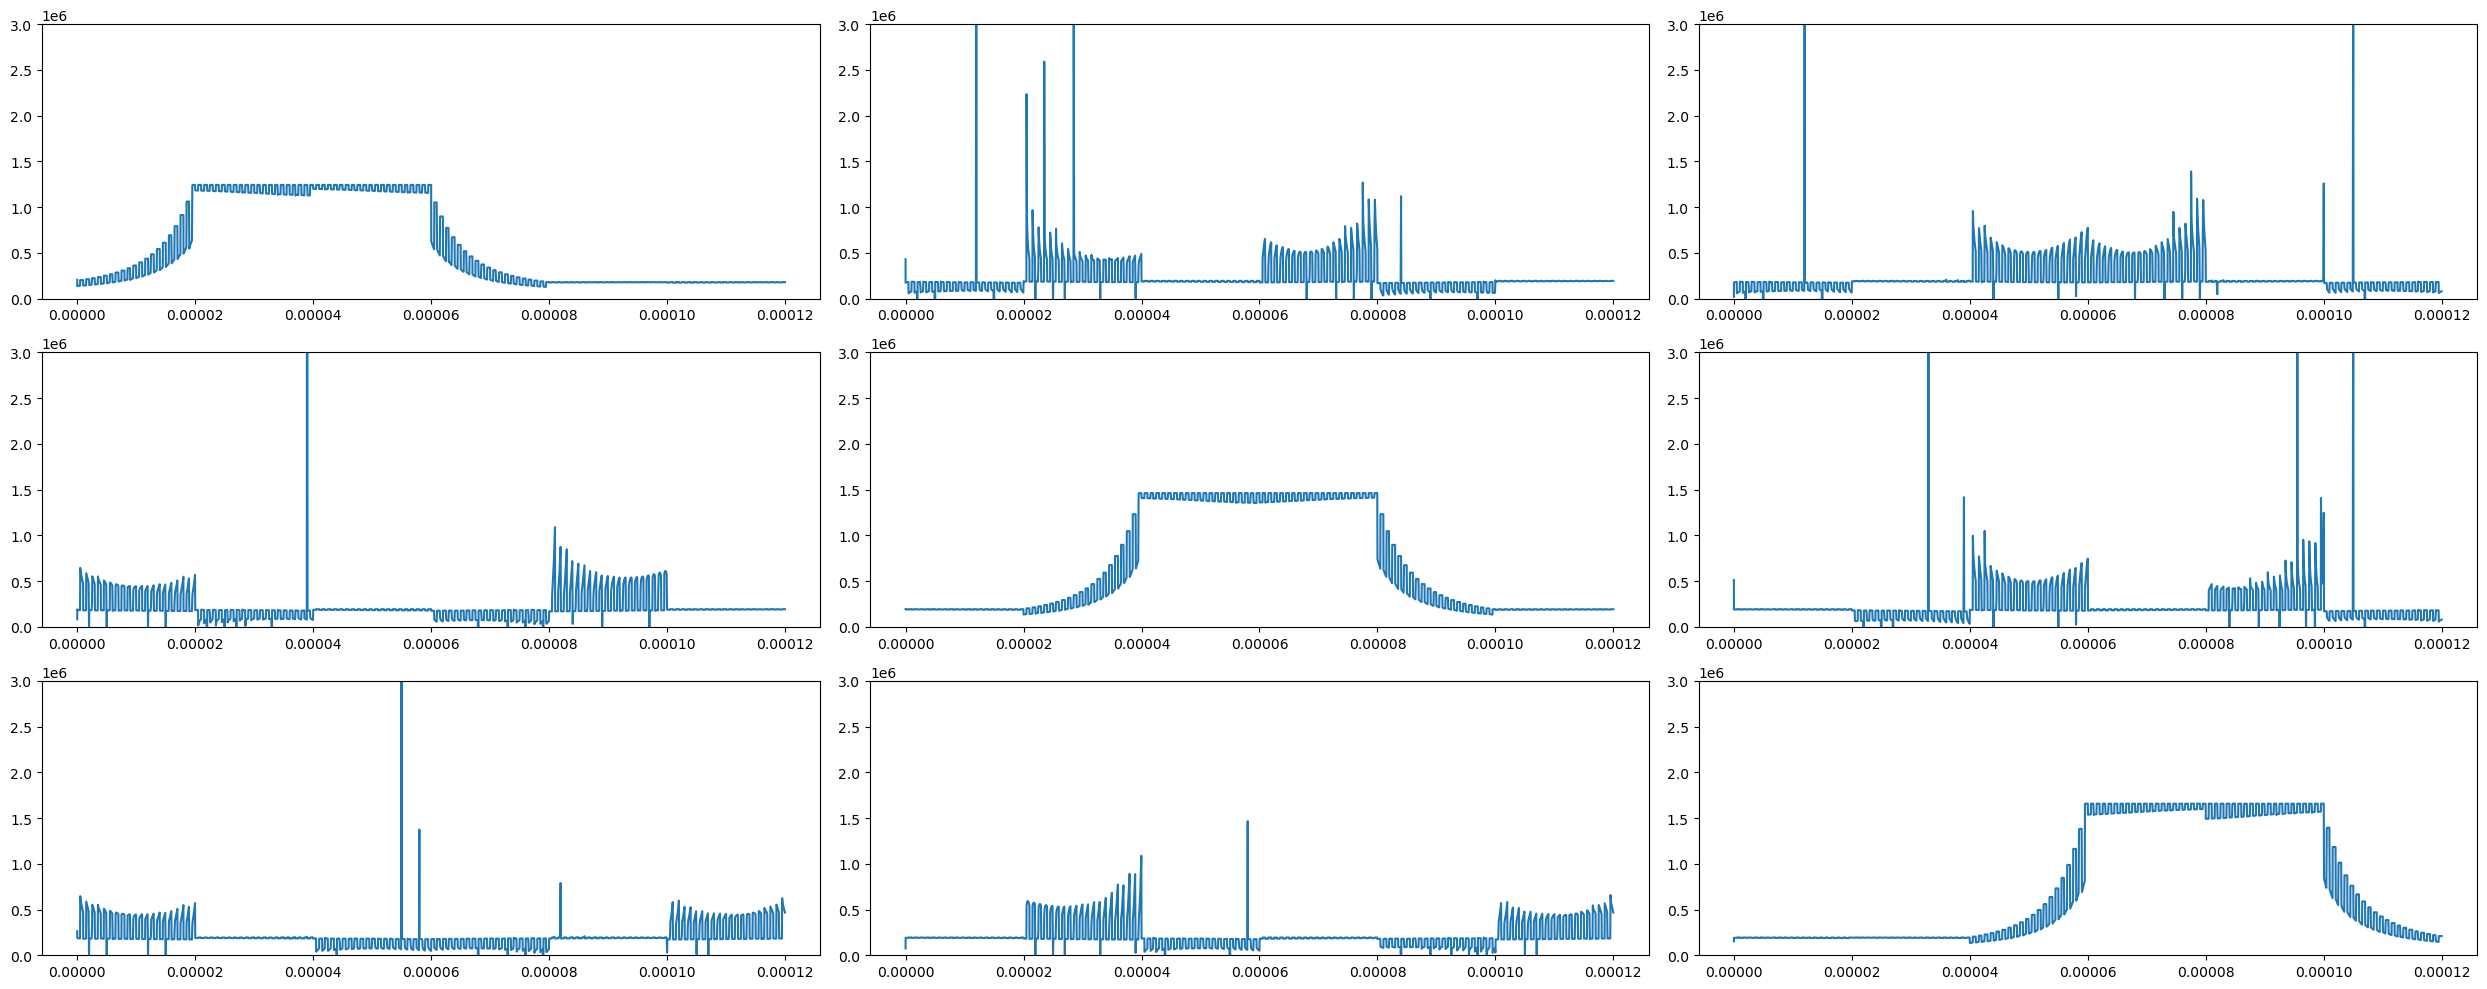

In [139]:


fig, axes = plt.subplots(3, 3, figsize=(25,10))

# Loop through each subplot
for i in range(3):
    for j in range(3):
        Imem = data[f'i(v.x1.vam{i+1}{j+1})'][::intp]
        vte = data[f'v(x1.te{i+1})'][::intp]
        vbe = data[f'v(x1.be{j+1})'][::intp]
        mem = (vbe - vte) / Imem
        axes[i, j].plot(data["time"][::intp], mem, label = f"i{i+1}{j+1}")
        axes[i,j].set_ylim(0, 3e6)

# Adjust spacing
plt.tight_layout()

# Show the figure
plt.show()



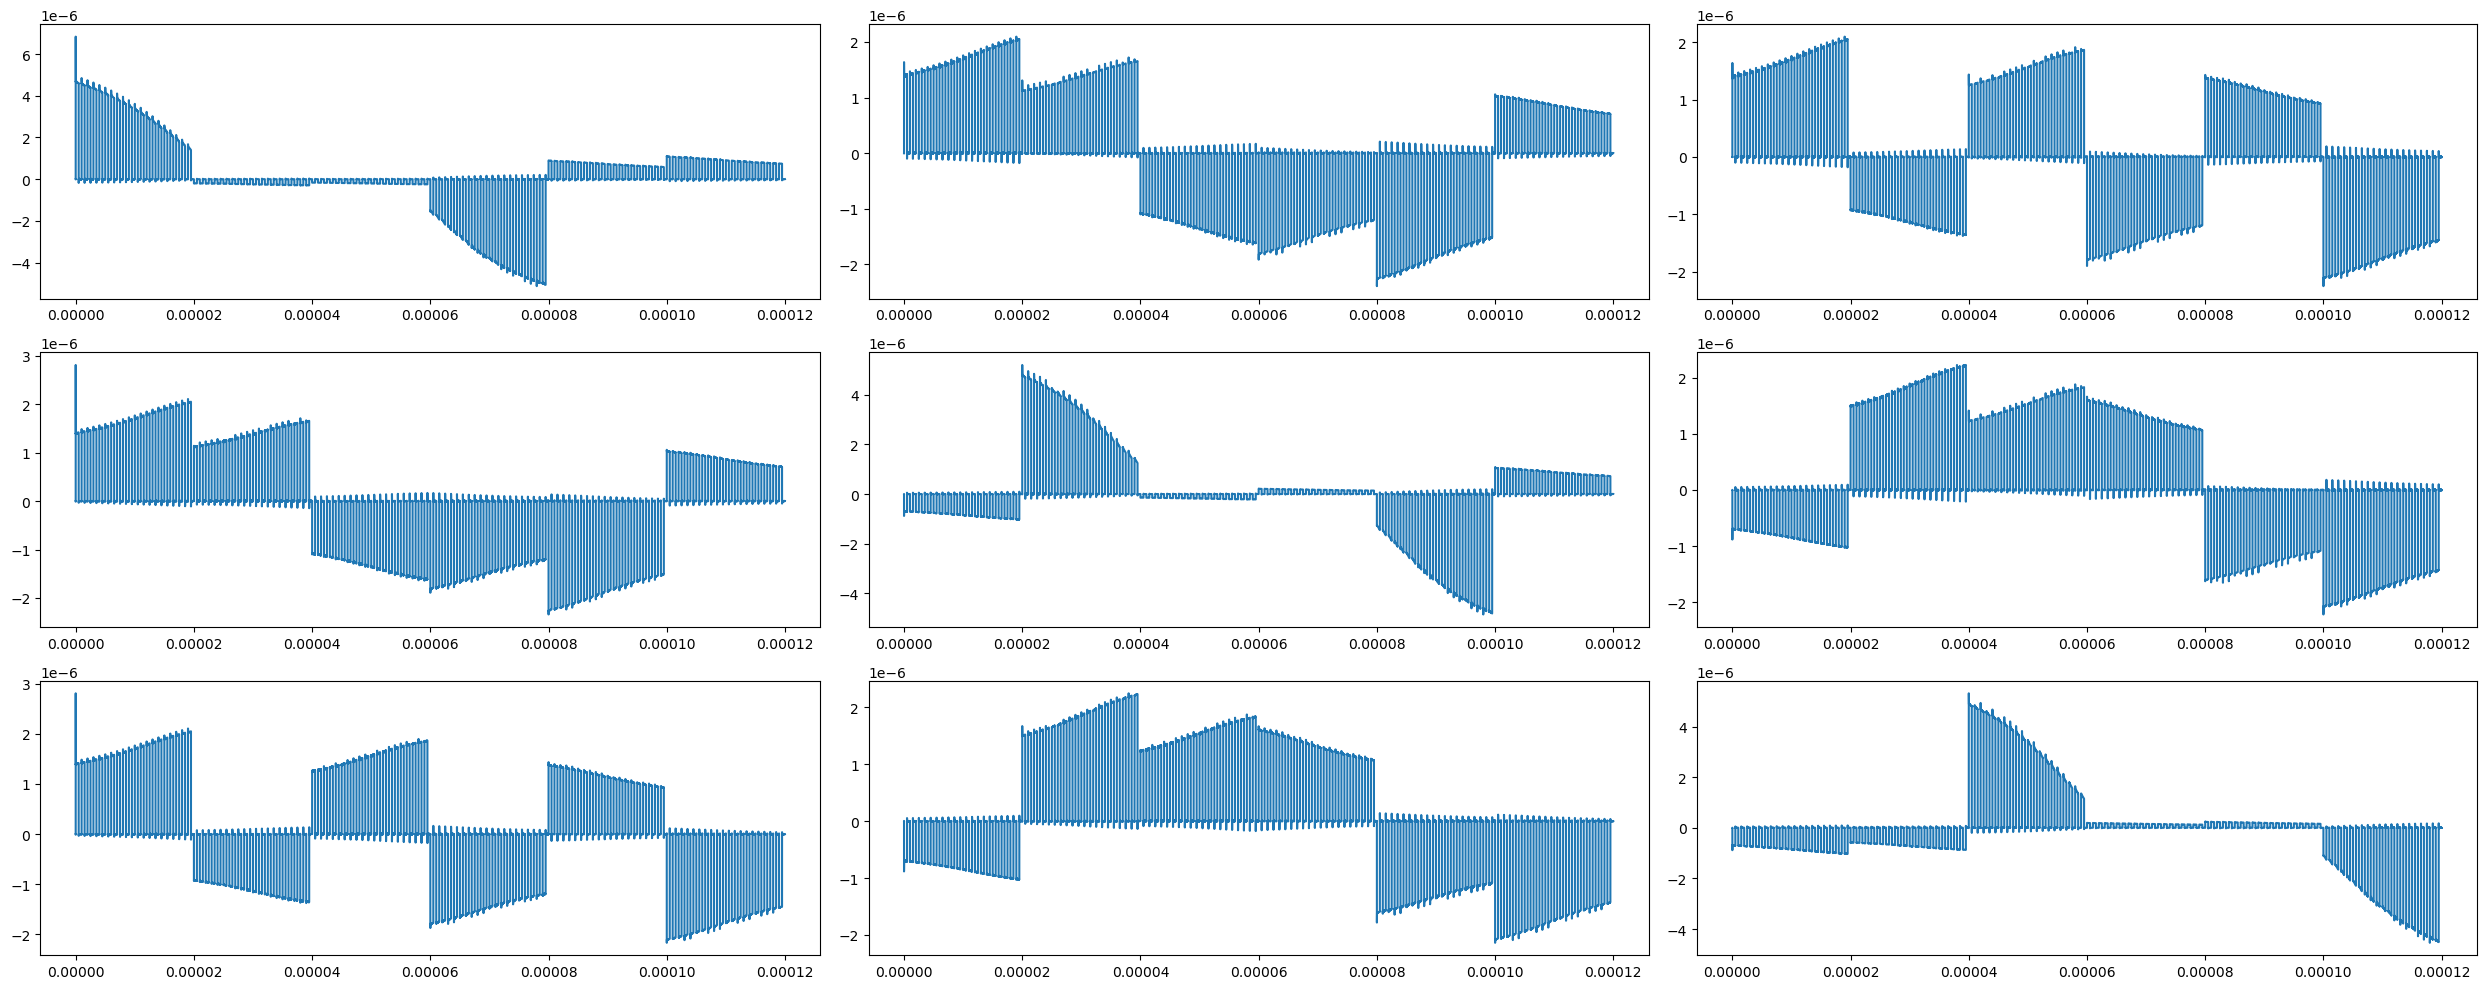

In [140]:


fig, axes = plt.subplots(3, 3, figsize=(25,10))

# Loop through each subplot
for i in range(3):
    for j in range(3):
        axes[i, j].plot(data["time"], data[f'i(v.x1.vam{i+1}{j+1})'], label = f"i{i+1}{j+1}")
# Adjust spacing
plt.tight_layout()

# Show the figure
plt.show()



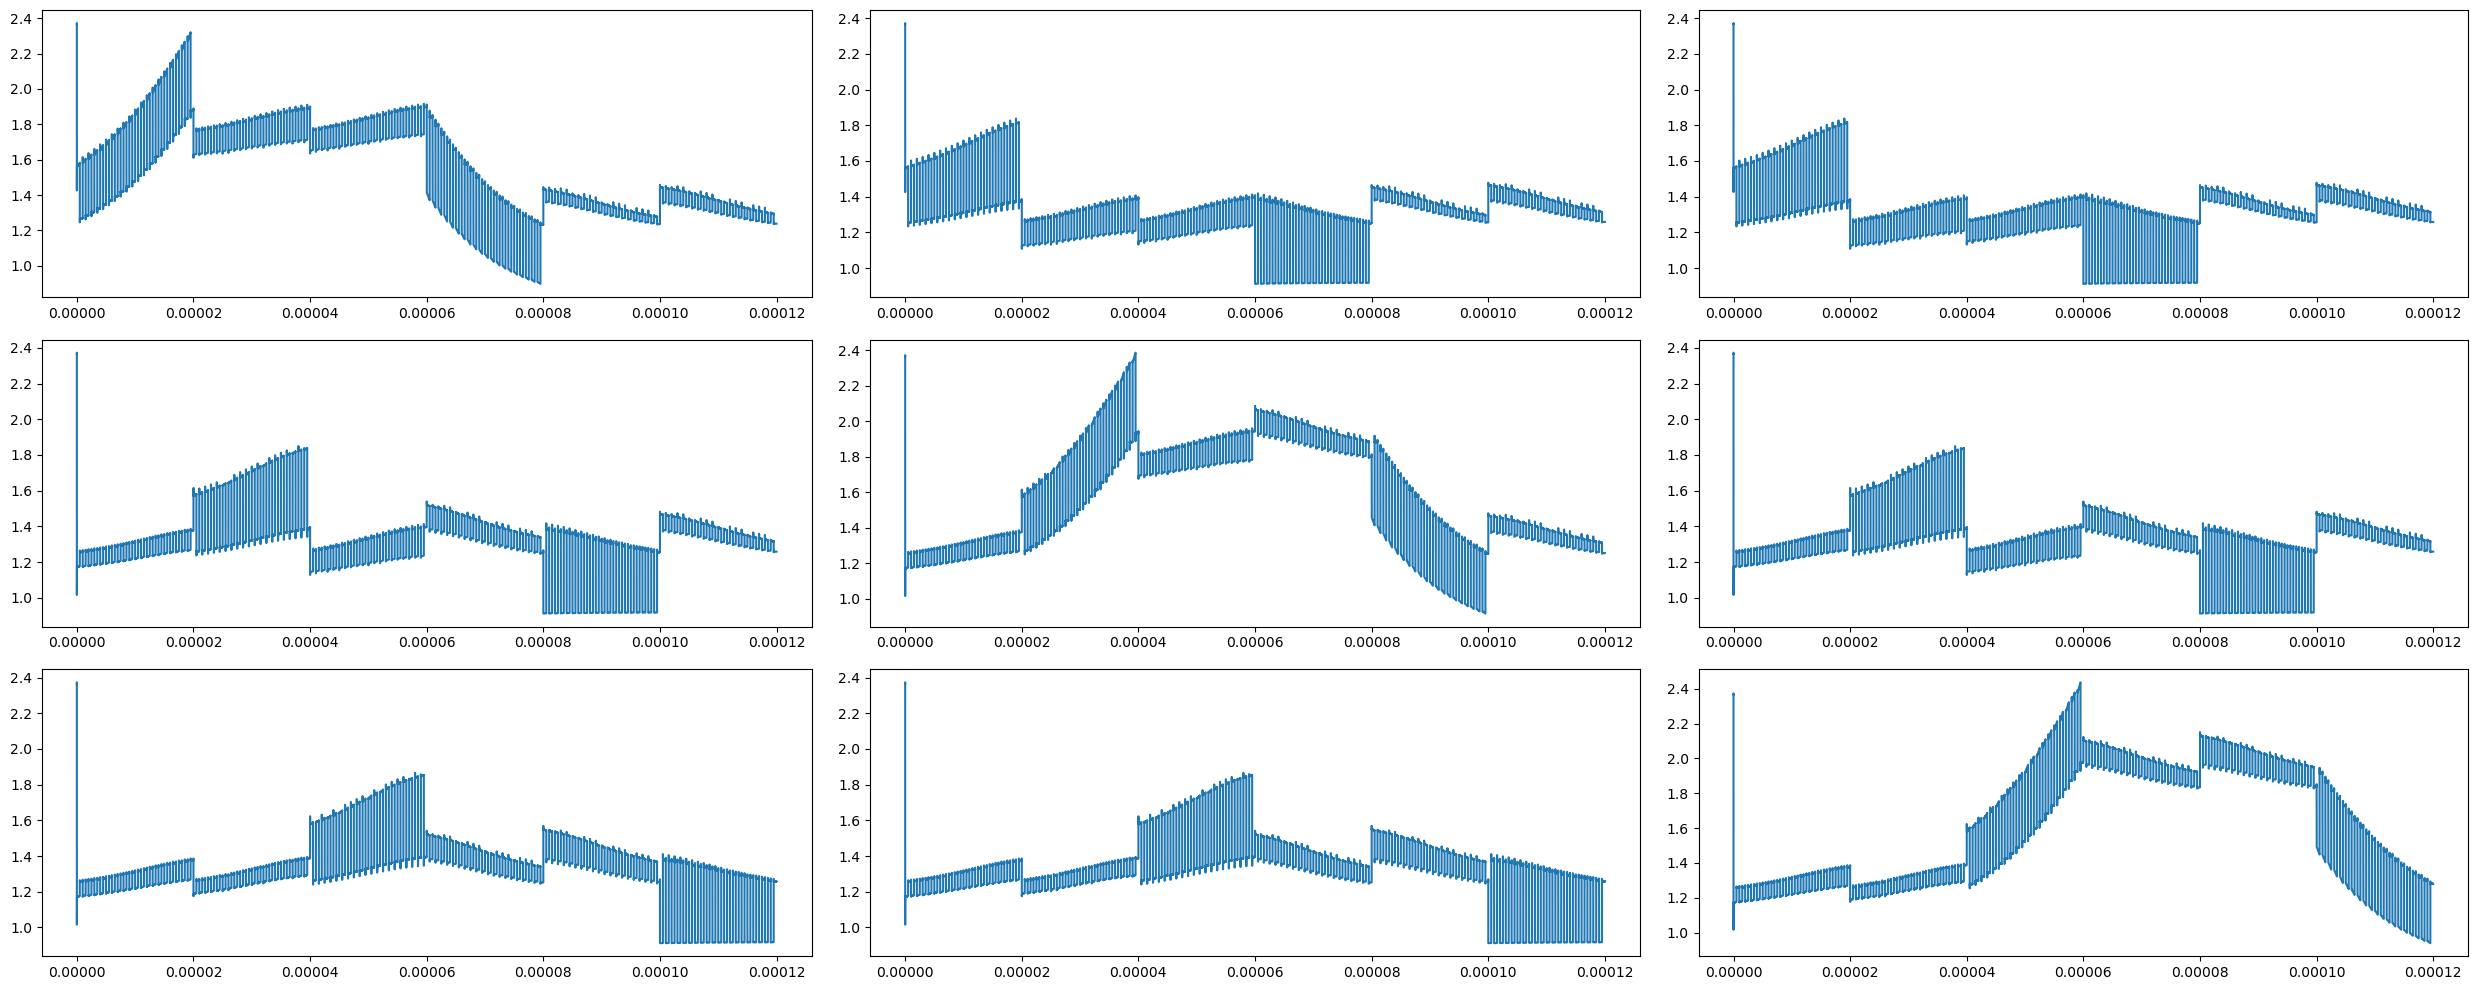

In [141]:





fig, axes = plt.subplots(3, 3, figsize=(25,10))

# Loop through each subplot
for i in range(3):
    for j in range(3):
        axes[i, j].plot(data["time"], data[f'v(n.x1.xr{i+1}{j+1}.n1#ngap)'], label = f"i{i+1}{j+1}")
# Adjust spacing
plt.tight_layout()

# Show the figure
plt.show()


